In [124]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

****load a Titanic dataset****

***datasetfrom kaggle***=https://www.kaggle.com/datasets/abdelrahmansaad10/titanic

In [125]:
data=pd.read_csv("Titanic.csv")
data.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


****check a null value and data info****

In [126]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

****rename a column "Unnamed: 0" to "s.no"****

In [127]:
data.rename(columns={"Unnamed: 0":"s.no"},inplace=True)

****Handel a missing value****

mean is used for "age"

mode is used for a "embarked"&"embark_town"

In [128]:
data["age"]=data["age"].fillna(data["age"].mean())
data["embarked"]=data["embarked"].fillna(data["embarked"].mode()[0])
data["embark_town"]=data["embark_town"].fillna(data["embark_town"].mode()[0])


In [129]:
data.isna().sum()

s.no             0
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

****Drop a "deck" column****

In [130]:
data.drop(columns="deck",inplace=True)

In [131]:
data.columns

Index(['s.no', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

***group a column by "age" & "survived"***

In [132]:
data.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

****plot a barplot for survived rate by gender****

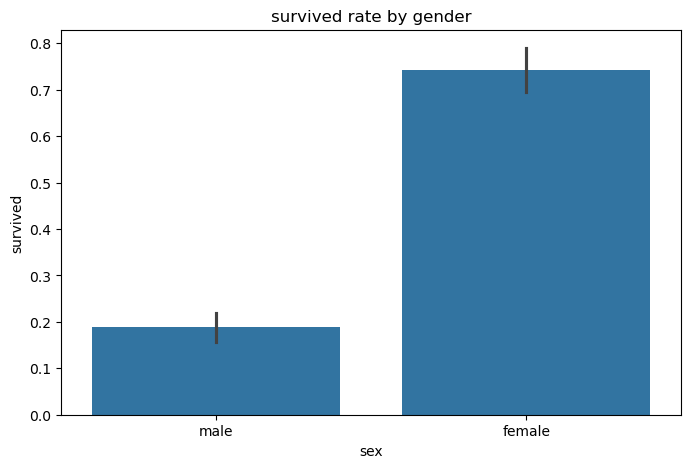

In [133]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="sex",
    y="survived",
    data=data
)
plt.title("survived rate by gender")
plt.xlabel("sex")
plt.ylabel("survived")
plt.show()

***group a column by "pclass" & "survived"***

In [134]:
data.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

****plot a barplot for survived rate by "pclass"****

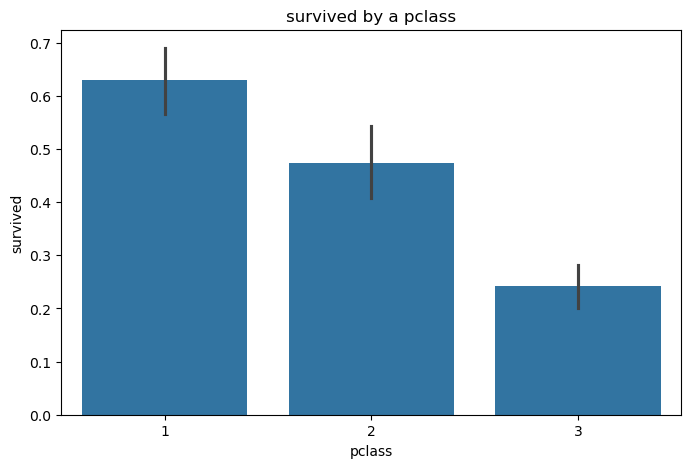

In [135]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="pclass",
    y="survived",
    data=data
)
plt.title("survived by a pclass")
plt.xlabel("pclass")
plt.ylabel("survived")
plt.show()

****create a new colunm seprate age colunm like 0to11 is child and 12to18 is teenager for better understand and survive chance****

In [136]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']
data['age_group'] = pd.cut(
    data['age'],
    bins=bins,
    labels=labels
)
data.head(10)

,s.no,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group
0,0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult
4,4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult
5,5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,Young Adult
6,6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,Southampton,no,True,Adult
7,7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,Southampton,no,False,Child
8,8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,Young Adult
9,9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,Teen


***group a column by "age_group" & "survived"***

In [137]:
data.groupby("age_group")["survived"].mean()

C:\Users\vishn\AppData\Local\Temp\ipykernel_30544\2965671000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("age_group")["survived"].mean()


age_group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64

****plot a barplot for survived rate by a new column****

<function matplotlib.pyplot.show(close=None, block=None)>

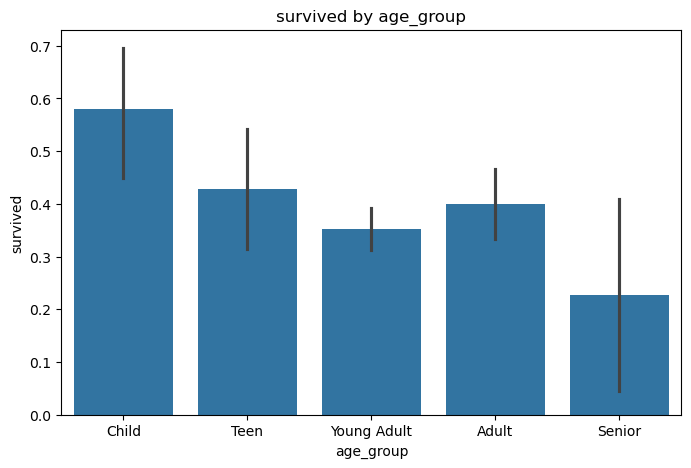

In [138]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="age_group",
    y="survived",
    data=data
)
plt.title("survived by age_group")
plt.xlabel("age_group")
plt.ylabel("survived")
plt.show

****plot a boxplot for age distribution****

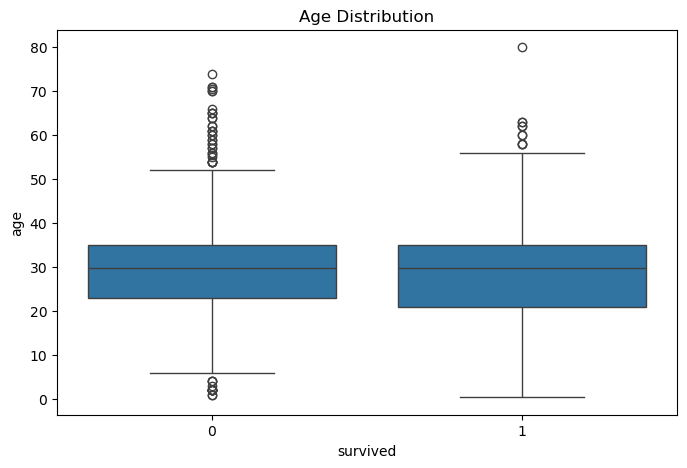

In [139]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='survived',
    y='age',
    data=data
)
plt.title('Age Distribution')
plt.xlabel("survived")
plt.ylabel("age")
plt.show()

****plot a violineplot for age distribution****

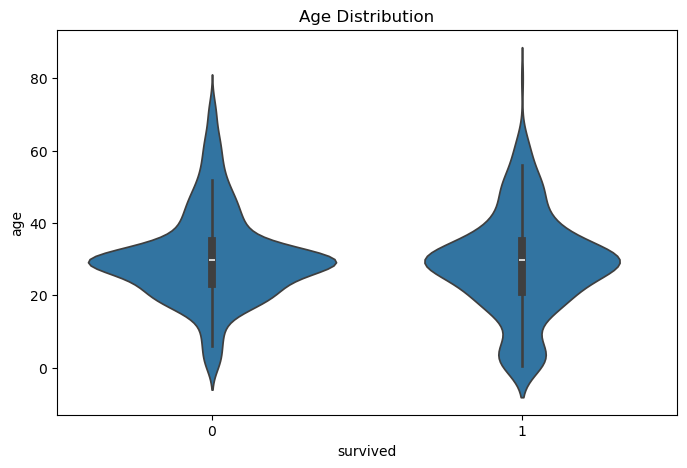

In [140]:
plt.figure(figsize=(8,5))
sns.violinplot(
    x='survived',
    y='age',
    data=data
)
plt.title('Age Distribution')
plt.xlabel("survived")
plt.ylabel("age")
plt.show()

****Create a column for only a numerical value****

In [141]:
num_col=data.select_dtypes(include=np.number)
corr_matrix = num_col.corr()

print(corr_matrix)


              s.no  survived    pclass       age     sibsp     parch      fare
s.no      1.000000 -0.005007 -0.035144  0.033207 -0.057527 -0.001652  0.012658
survived -0.005007  1.000000 -0.338481 -0.069809 -0.035322  0.081629  0.257307
pclass   -0.035144 -0.338481  1.000000 -0.331339  0.083081  0.018443 -0.549500
age       0.033207 -0.069809 -0.331339  1.000000 -0.232625 -0.179191  0.091566
sibsp    -0.057527 -0.035322  0.083081 -0.232625  1.000000  0.414838  0.159651
parch    -0.001652  0.081629  0.018443 -0.179191  0.414838  1.000000  0.216225
fare      0.012658  0.257307 -0.549500  0.091566  0.159651  0.216225  1.000000


****plot a heatmap of the numeric column****

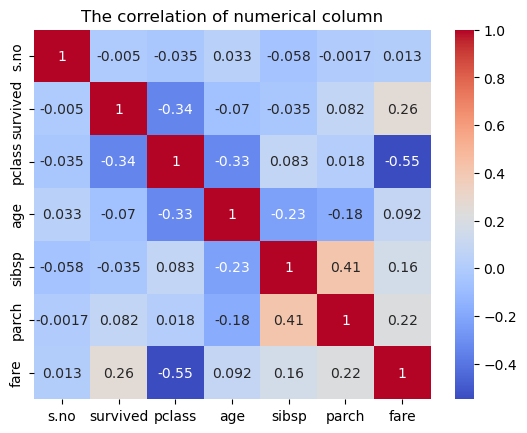

In [ ]:
sns.heatmap(
    num_col.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("The correlation of numerical column")
plt.show()

****1)Female passengers had a much higher survival rate than male passengers.****

****2)First-class passengers had the highest chance of survival.****

****3)Third-class passengers had the lowest survival rate.****

****4)Children had a better chance of survival compared to adults.****

****5)Age and passenger class both influenced survival.****